































# Aproximacion Polinomial de Curvas

---

## Que vamos a hacer aqui?

Tenemos un dataset con **500 curvas**. Cada curva existe en dos formatos:

- **`target/`** : La curva "real", continua, con 8,000 puntos de alta precision.
- **`pixel_curves/`** : La misma curva pero **discretizada** (redondeada a pixeles enteros) a 5 escalas diferentes.

La idea es: dado que solo tenemos versiones pixelizadas, **podemos usar polinomios para reconstruir una curva suave** que se acerque lo mas posible a la curva real?

### Estructura del notebook

1. Entendiendo nuestros datos
2. Que es una aproximacion polinomial?
3. Ajustando polinomios a las curvas target
4. Ajustando polinomios a las curvas pixelizadas
5. Comparacion: pixel vs target vs polinomio
6. Encontrando el grado optimo
7. Analisis de errores
8. Conclusiones

---

## 1. Entendiendo nuestros datos

Antes de aproximar nada, entendamos que tenemos.

Cada curva tiene **6 archivos**:

| Archivo | Tipo | Escala | Separador | Valores |
|---------|------|--------|-----------|--------|
| `curve_XXXX.txt` | target | - | coma | flotantes |
| `curve_XXXX_X10.txt` | pixel | 1.0x | espacio | enteros |
| `curve_XXXX_X15.txt` | pixel | 1.5x | espacio | enteros |
| `curve_XXXX_X18.txt` | pixel | 1.8x | espacio | enteros |
| `curve_XXXX_X21.txt` | pixel | 2.1x | espacio | enteros |
| `curve_XXXX_X25.txt` | pixel | 2.5x | espacio | enteros |

### Relacion entre pixel y target

Las coordenadas pixel son versiones **escaladas y redondeadas** de las coordenadas target:

$$\text{pixel}_{x} \approx \text{round}\left(\text{target}_{x} \times \frac{X_{val}}{10}\right)$$

$$\text{pixel}_{y} \approx \text{round}\left(\text{target}_{y} \times \frac{X_{val}}{10}\right)$$

Es decir, para recuperar coordenadas en el espacio original:

$$\text{target}_{x} \approx \frac{\text{pixel}_{x}}{X_{val} / 10}$$

A mayor escala (X25), mas puntos y mas detalle. A menor escala (X10), menos puntos y mas error de redondeo.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': [14, 6],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11
})

# Rutas
BASE = Path('.')
TARGET = BASE / 'curves' / 'datos' / 'target'
PIXEL  = BASE / 'curves' / 'datos' / 'pixel_curves'

SCALES = {10: 1.0, 15: 1.5, 18: 1.8, 21: 2.1, 25: 2.5}

#------- funciones de carga-------
def load_target(cid):
    d = np.loadtxt(TARGET / f'curve_{cid:04d}.txt', delimiter=',')
    return d[:, 0], d[:, 1]

def load_pixel(cid, xval):
    d = np.loadtxt(PIXEL / f'curve_{cid:04d}_X{xval}.txt')
    return d[:, 0], d[:, 1]

def pixel_to_target_coords(px, py, xval):
    """Convierte coordenadas pixel al espacio del target."""
    scale = xval / 10.0
    return px / scale, py / scale

print("Todo listo.")

Todo listo.


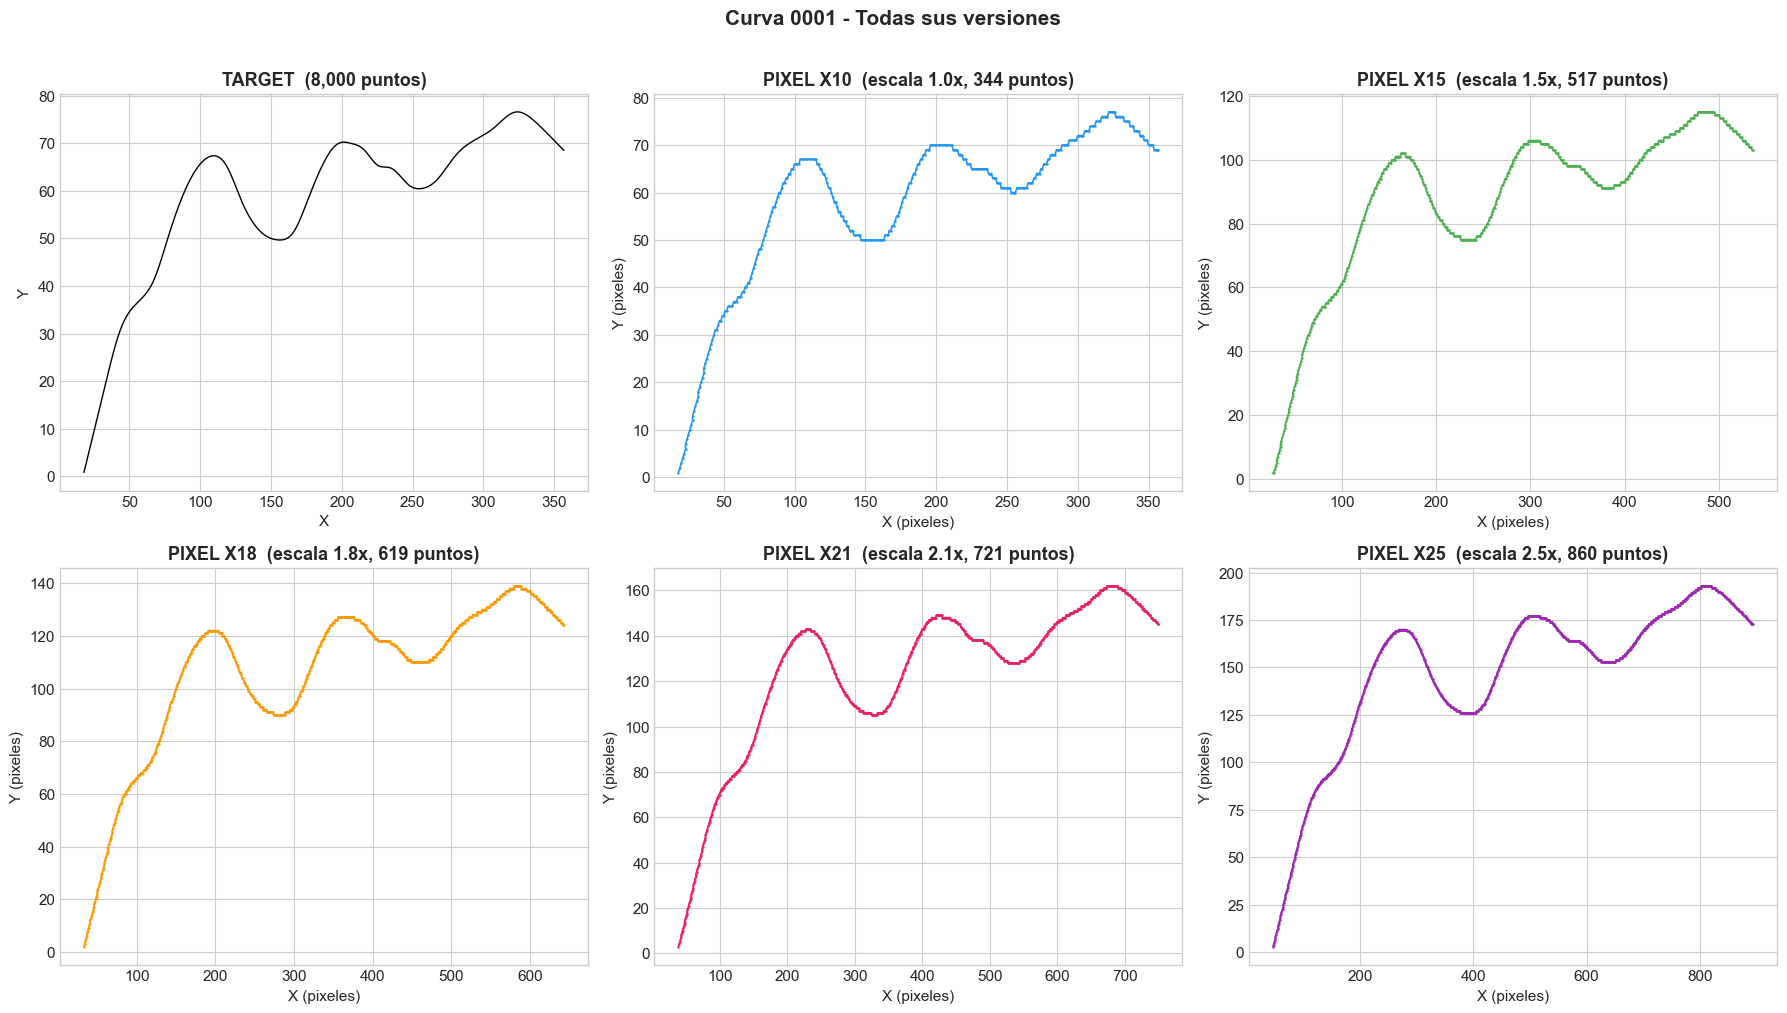

In [6]:
# Veamos como se ve una curva en sus 6 versiones
CID = 1  # curva de ejemplo

tx, ty = load_target(CID)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Target
axes[0, 0].plot(tx, ty, color='black', linewidth=1)
axes[0, 0].set_title(f'TARGET  ({len(tx):,} puntos)')
axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Y')

# Pixels
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for idx, xval in enumerate([10, 15, 18, 21, 25]):
    px, py = load_pixel(CID, xval)
    r, c = divmod(idx + 1, 3)
    ax = axes[r, c]
    ax.plot(px, py, color=colors[idx], linewidth=1.2, marker='.', markersize=1.5)
    ax.set_title(f'PIXEL X{xval}  (escala {SCALES[xval]}x, {len(px)} puntos)')
    ax.set_xlabel('X (pixeles)'); ax.set_ylabel('Y (pixeles)')

fig.suptitle(f'Curva {CID:04d} - Todas sus versiones', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

A primera vista se ven iguales, pero hay diferencias importantes:
- El **target** tiene 8,000 puntos y coordenadas continuas.
- Los **pixel** tienen menos puntos y coordenadas enteras.

Eso "escalonado" es el **ruido de discretizacion** que queremos suavizar con polinomios.

Veamoslo con un **zoom** para apreciar la diferencia:

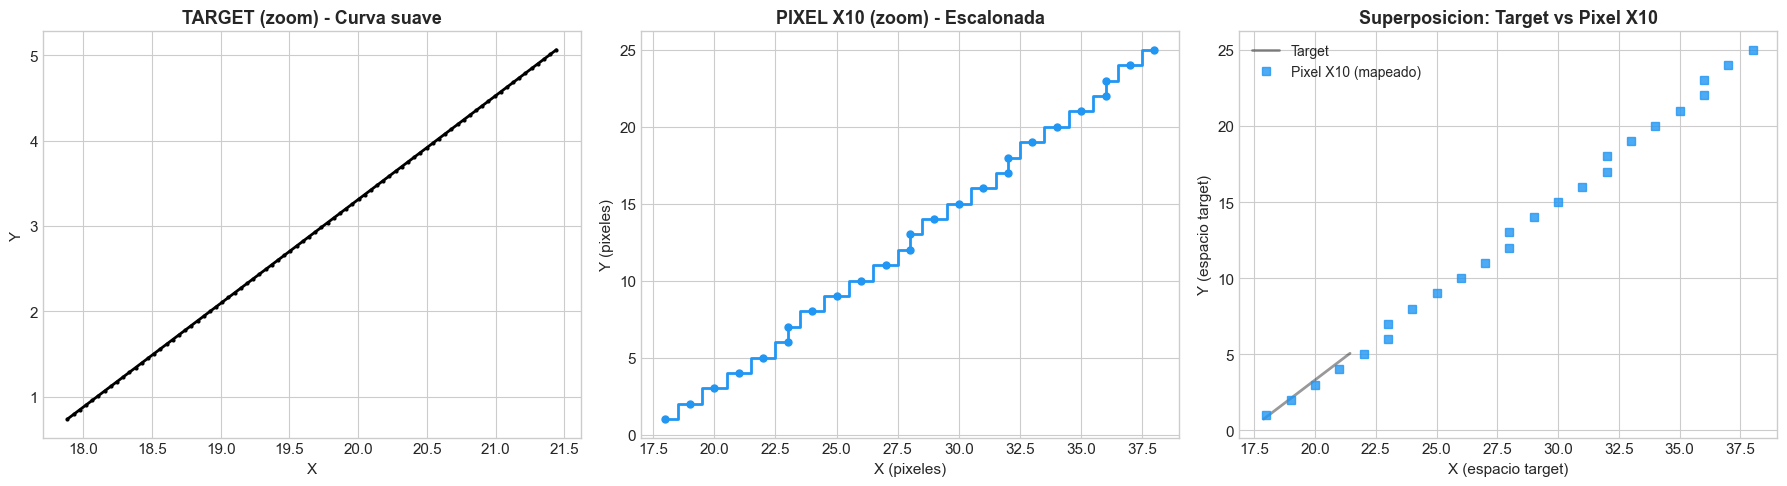

Observa el 'escalonado' en la version pixel: eso es el ruido de discretizacion.
Nuestro objetivo: usar polinomios para suavizar esos escalones.


In [7]:
# Zoom comparativo: target continuo vs pixel discreto
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Seleccionar region de zoom (primeros puntos)
zoom_n = 80

# Target (zoom)
axes[0].plot(tx[:zoom_n], ty[:zoom_n], 'k-', linewidth=2, label='Target')
axes[0].plot(tx[:zoom_n], ty[:zoom_n], 'ko', markersize=2)
axes[0].set_title('TARGET (zoom) - Curva suave')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

# Pixel X10 (zoom) - peor resolucion
px10, py10 = load_pixel(CID, 10)
axes[1].step(px10[:25], py10[:25], where='mid', color='#2196F3', linewidth=2, label='Pixel X10')
axes[1].plot(px10[:25], py10[:25], 'o', color='#2196F3', markersize=5)
axes[1].set_title('PIXEL X10 (zoom) - Escalonada')
axes[1].set_xlabel('X (pixeles)'); axes[1].set_ylabel('Y (pixeles)')

# Superposicion: pixel mapeado vs target
mx10, my10 = pixel_to_target_coords(px10, py10, 10)
axes[2].plot(tx[:zoom_n], ty[:zoom_n], 'k-', linewidth=2, alpha=0.4, label='Target')
axes[2].plot(mx10[:25], my10[:25], 's', color='#2196F3', markersize=6, alpha=0.8, label='Pixel X10 (mapeado)')
axes[2].set_title('Superposicion: Target vs Pixel X10')
axes[2].set_xlabel('X (espacio target)'); axes[2].set_ylabel('Y (espacio target)')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Observa el 'escalonado' en la version pixel: eso es el ruido de discretizacion.")
print("Nuestro objetivo: usar polinomios para suavizar esos escalones.")

---

## 2. Que es una aproximacion polinomial?

Un **polinomio de grado n** es una funcion de la forma:

$$P_n(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0$$

La idea es encontrar los coeficientes $a_0, a_1, \ldots, a_n$ que hagan que $P_n(x)$ se parezca lo mas posible a nuestra curva.

### Ejemplos intuitivos

| Grado | Nombre | Forma | Se ve como... |
|-------|--------|-------|---------------|
| 1 | Lineal | $ax + b$ | Una linea recta |
| 2 | Cuadratica | $ax^2 + bx + c$ | Una parabola |
| 3 | Cubica | $ax^3 + bx^2 + cx + d$ | Forma de S |

### El dilema

- **Grado muy bajo**: El polinomio es demasiado simple y no captura la forma real. (**Subajuste**)
- **Grado muy alto**: El polinomio empieza a "memorizar" los errores y oscila mucho entre los puntos. (**Sobreajuste**)
- **Grado justo**: Captura la tendencia real sin copiar el ruido.

Vamos a buscar ese **punto justo**.

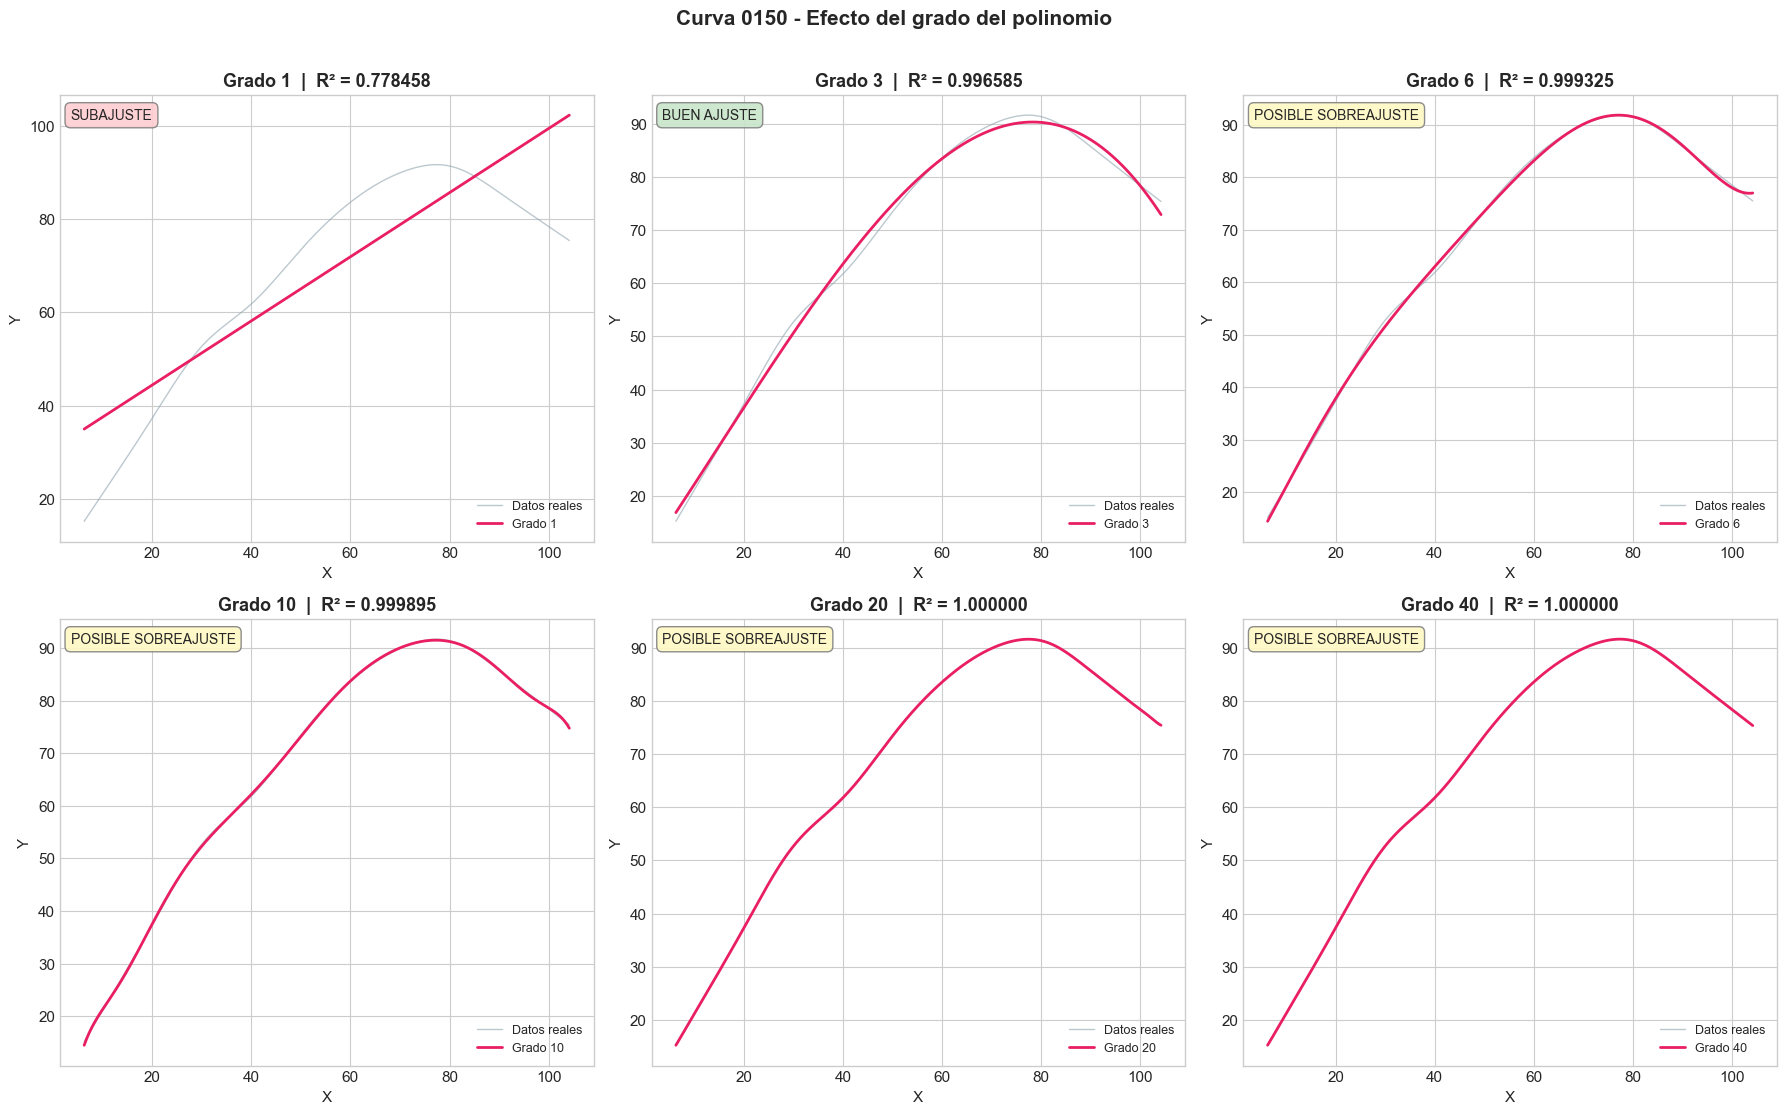

In [8]:
# Demostrar subajuste vs sobreajuste con un ejemplo
CID = 150  # una curva con forma interesante
tx, ty = load_target(CID)

# Submuestrear para rapidez
idx = np.linspace(0, len(tx)-1, 500).astype(int)
xs, ys = tx[idx], ty[idx]

degrees = [1, 3, 6, 10, 20, 40]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, deg in enumerate(degrees):
    ax = axes[i]
    
    # Ajustar
    coeffs = np.polyfit(xs, ys, deg)
    poly = np.poly1d(coeffs)
    y_pred = poly(xs)
    r2 = r2_score(ys, y_pred)
    
    # Graficar
    ax.plot(xs, ys, color='#90A4AE', linewidth=1, alpha=0.6, label='Datos reales')
    ax.plot(xs, y_pred, color='#E91E63', linewidth=2, label=f'Grado {deg}')
    
    # Etiqueta de calidad
    if r2 < 0.8:
        etiqueta, color_bg = 'SUBAJUSTE', '#FFCDD2'
    elif r2 > 0.999:
        etiqueta, color_bg = 'POSIBLE SOBREAJUSTE', '#FFF9C4'
    else:
        etiqueta, color_bg = 'BUEN AJUSTE', '#C8E6C9'
    
    ax.set_title(f'Grado {deg}  |  R² = {r2:.6f}')
    ax.text(0.02, 0.97, etiqueta, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.4',
            facecolor=color_bg, alpha=0.9, edgecolor='gray'))
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle(f'Curva {CID:04d} - Efecto del grado del polinomio',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Observaciones:

- **Grado 1 (lineal)**: Una recta, no captura la curvatura. Subajuste claro.
- **Grado 3**: Empieza a capturar la tendencia general.
- **Grado 6-10**: Buen ajuste, captura bien la forma.
- **Grado 20-40**: Se ve igual que grado 10 visualmente, pero numericamente puede volverse inestable.

La clave no es usar el grado mas alto posible, sino el grado **mas bajo que sea suficiente**.

---

## 3. Ajustando polinomios a las curvas target

Vamos a probar con varias curvas y diferentes grados para ver como se comporta el ajuste polinomial sobre los datos de alta precision.

In [9]:
# Seleccion de curvas representativas
CURVAS = [1, 50, 100, 150, 250, 400]
GRADOS = list(range(1, 16))  # grado 1 al 15

# Calcular R2 para cada curva y grado
resultados_target = []

for cid in CURVAS:
    tx, ty = load_target(cid)
    idx = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs, ys = tx[idx], ty[idx]
    
    for deg in GRADOS:
        coeffs = np.polyfit(xs, ys, deg)
        y_pred = np.poly1d(coeffs)(xs)
        r2 = r2_score(ys, y_pred)
        rmse = np.sqrt(mean_squared_error(ys, y_pred))
        mae = mean_absolute_error(ys, y_pred)
        
        resultados_target.append({
            'curva': cid, 'grado': deg,
            'r2': r2, 'rmse': rmse, 'mae': mae
        })

df_target = pd.DataFrame(resultados_target)
print(f"Resultados calculados: {len(df_target)} combinaciones curva-grado")

Resultados calculados: 90 combinaciones curva-grado


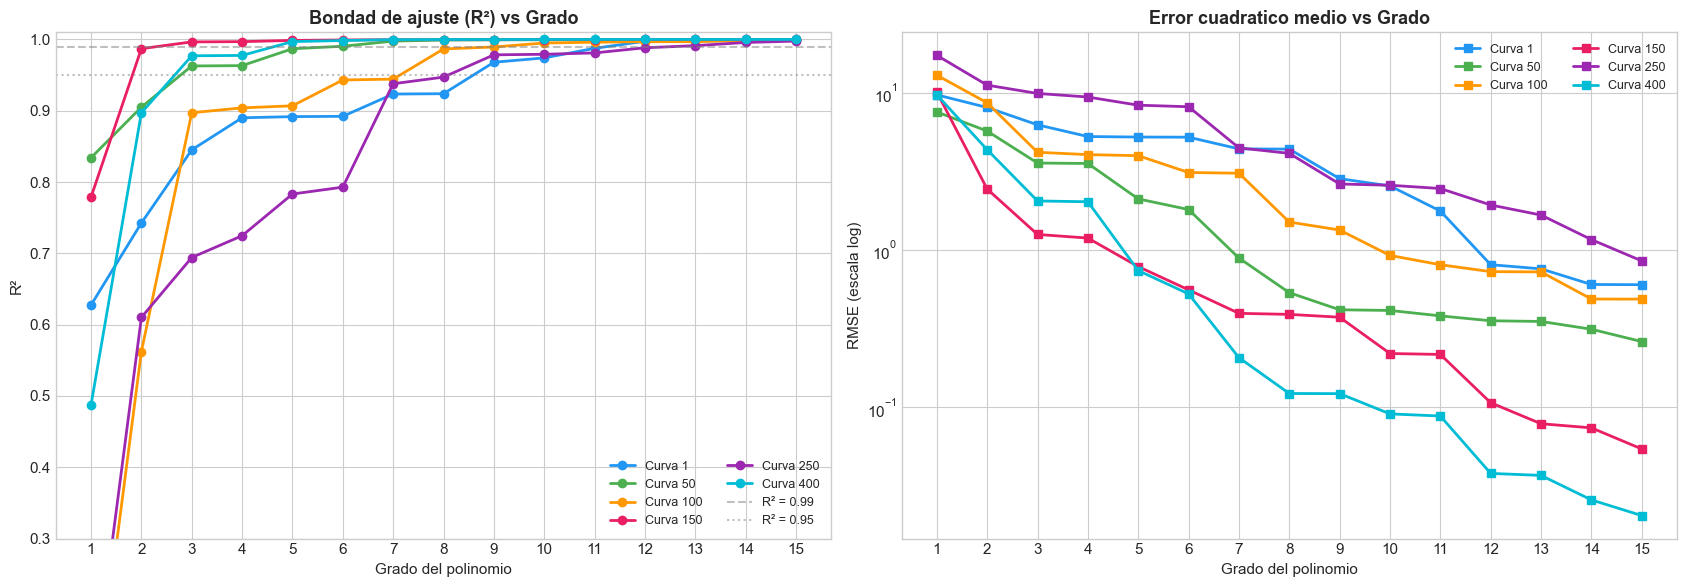

Lectura: las curvas R2 suben rapido y luego se estabilizan.
El RMSE baja rapido al principio y luego se aplana.
Esto nos dice que hay un punto donde agregar mas grado ya no ayuda mucho.


In [10]:
# Grafica principal: R2 vs grado para cada curva
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

palette = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

# Panel izquierdo: R2
for i, cid in enumerate(CURVAS):
    sub = df_target[df_target['curva'] == cid]
    axes[0].plot(sub['grado'], sub['r2'], 'o-', color=palette[i],
                linewidth=2, markersize=6, label=f'Curva {cid}')

axes[0].axhline(0.99, color='gray', linestyle='--', alpha=0.5, label='R² = 0.99')
axes[0].axhline(0.95, color='gray', linestyle=':', alpha=0.5, label='R² = 0.95')
axes[0].set_xlabel('Grado del polinomio')
axes[0].set_ylabel('R²')
axes[0].set_title('Bondad de ajuste (R²) vs Grado')
axes[0].legend(fontsize=9, ncol=2)
axes[0].set_ylim(0.3, 1.01)
axes[0].set_xticks(GRADOS)

# Panel derecho: RMSE
for i, cid in enumerate(CURVAS):
    sub = df_target[df_target['curva'] == cid]
    axes[1].semilogy(sub['grado'], sub['rmse'], 's-', color=palette[i],
                    linewidth=2, markersize=6, label=f'Curva {cid}')

axes[1].set_xlabel('Grado del polinomio')
axes[1].set_ylabel('RMSE (escala log)')
axes[1].set_title('Error cuadratico medio vs Grado')
axes[1].legend(fontsize=9, ncol=2)
axes[1].set_xticks(GRADOS)

plt.tight_layout()
plt.show()

print("Lectura: las curvas R2 suben rapido y luego se estabilizan.")
print("El RMSE baja rapido al principio y luego se aplana.")
print("Esto nos dice que hay un punto donde agregar mas grado ya no ayuda mucho.")

In [11]:
# Tabla resumen: grado minimo para alcanzar R2 > 0.99
print("Grado minimo necesario para R² > 0.99 en cada curva:\n")
print(f"{'Curva':>8} {'Grado min':>12} {'R² alcanzado':>14} {'RMSE':>10}")
print("-" * 48)

for cid in CURVAS:
    sub = df_target[(df_target['curva'] == cid) & (df_target['r2'] >= 0.99)]
    if len(sub) > 0:
        best = sub.iloc[0]
        print(f"{cid:>8} {int(best['grado']):>12} {best['r2']:>14.6f} {best['rmse']:>10.4f}")
    else:
        print(f"{cid:>8} {'> 15':>12} {'< 0.99':>14}")

Grado minimo necesario para R² > 0.99 en cada curva:

   Curva    Grado min   R² alcanzado       RMSE
------------------------------------------------
       1           12       0.997427     0.8085
      50            6       0.990483     1.8135
     100           10       0.994997     0.9258
     150            3       0.996583     1.2593
     250           13       0.991324     1.6730
     400            5       0.997017     0.7422


### Que observamos?

- La mayoria de curvas alcanzan un R² > 0.99 con polinomios de **grado 6 a 10**.
- Algunas curvas mas "complicadas" necesitan grados mas altos.
- Despues del grado optimo, seguir aumentando el grado no mejora significativamente.

Veamos ahora como se ven estos ajustes visualmente:

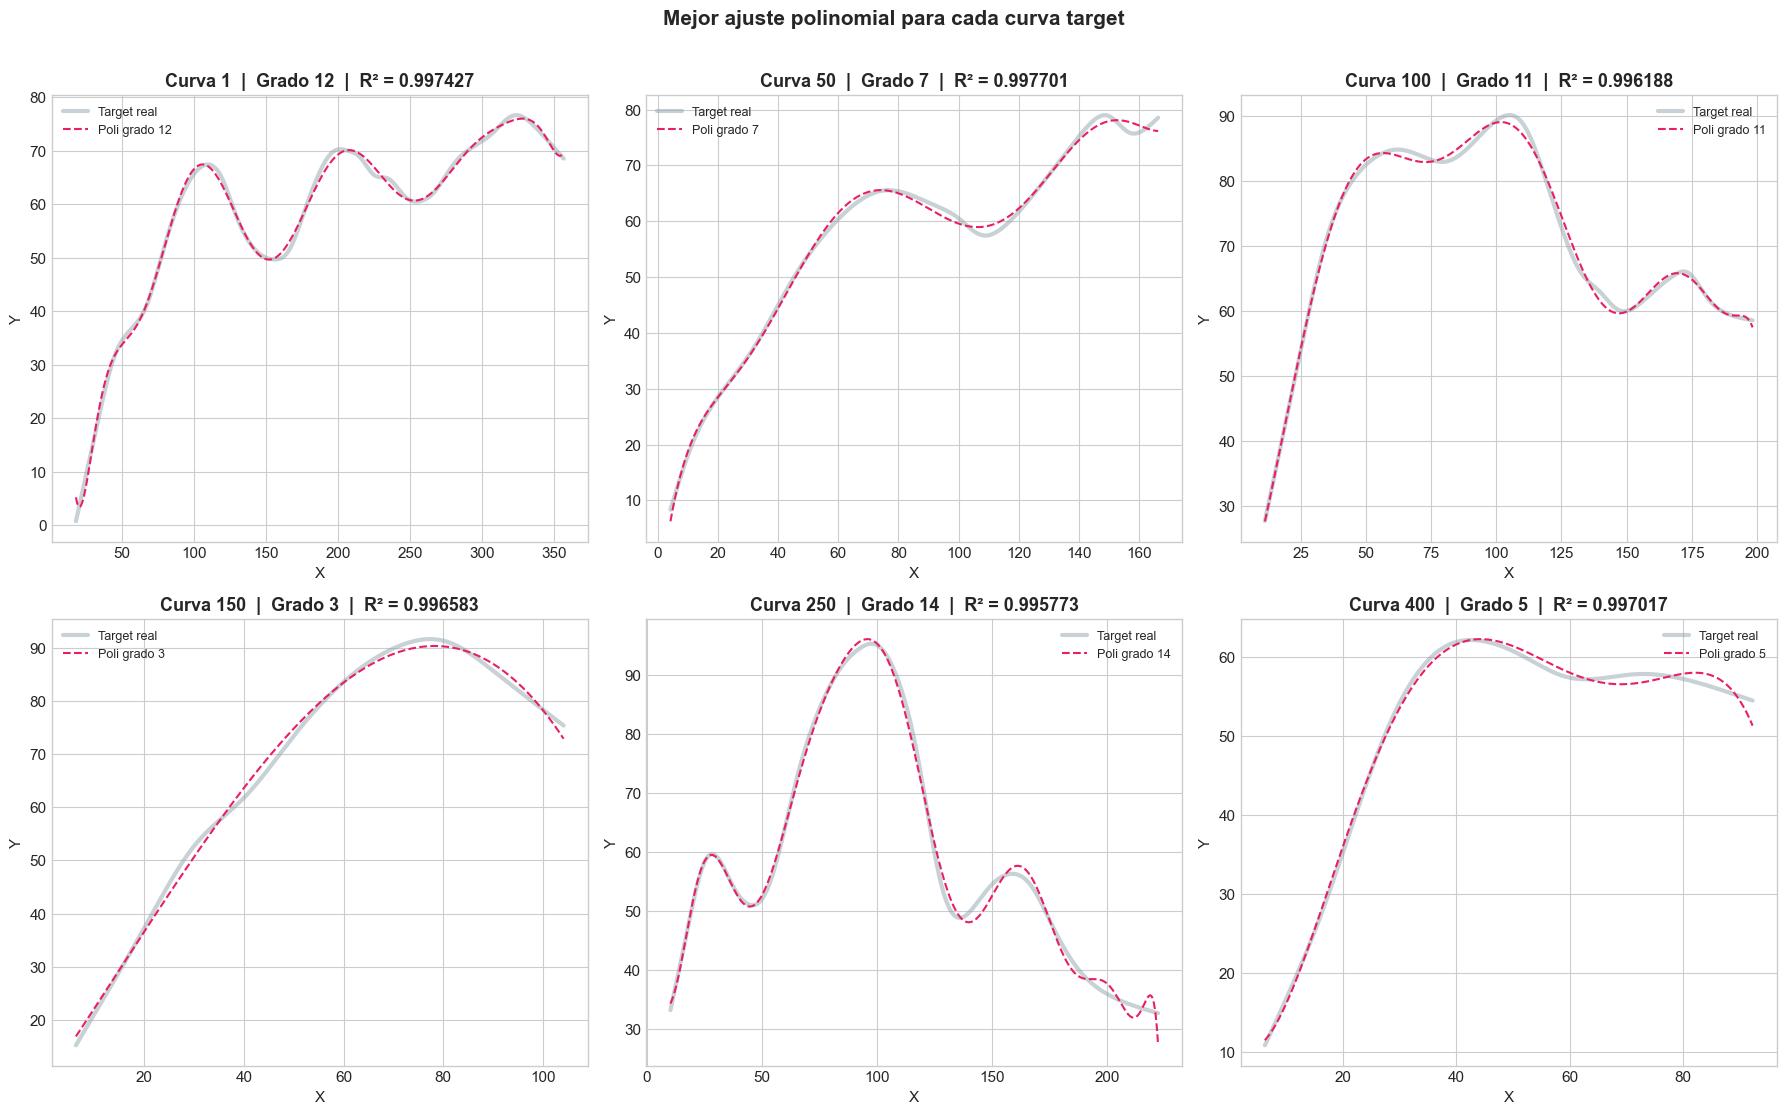

In [12]:
# Visualizacion: mejor ajuste para cada curva
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, cid in enumerate(CURVAS):
    ax = axes[i]
    tx, ty = load_target(cid)
    idx = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs, ys = tx[idx], ty[idx]
    
    # Encontrar mejor grado (primer grado con R2 > 0.995)
    sub = df_target[(df_target['curva'] == cid) & (df_target['r2'] >= 0.995)]
    best_deg = int(sub.iloc[0]['grado']) if len(sub) > 0 else 10
    best_r2 = sub.iloc[0]['r2'] if len(sub) > 0 else 0
    
    # Ajustar
    coeffs = np.polyfit(xs, ys, best_deg)
    y_pred = np.poly1d(coeffs)(xs)
    residuos = ys - y_pred
    
    # Graficar curva real vs ajuste
    ax.plot(xs, ys, color='#90A4AE', linewidth=3, alpha=0.5, label='Target real')
    ax.plot(xs, y_pred, color='#E91E63', linewidth=1.5, linestyle='--', label=f'Poli grado {best_deg}')
    
    ax.set_title(f'Curva {cid}  |  Grado {best_deg}  |  R² = {best_r2:.6f}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(fontsize=9)

fig.suptitle('Mejor ajuste polinomial para cada curva target',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Ajustando polinomios a las curvas pixelizadas

Ahora viene lo interesante. En la practica, **no tenemos acceso al target** (es lo que queremos reconstruir). Solo tenemos las versiones pixelizadas.

La pregunta es: **si ajustamos un polinomio sobre los datos pixelizados, se acerca al target real?**

Vamos a:
1. Tomar los puntos pixel (convertidos al espacio target)
2. Ajustar un polinomio sobre ellos
3. Evaluar ese polinomio en los puntos X del target
4. Comparar con el target real

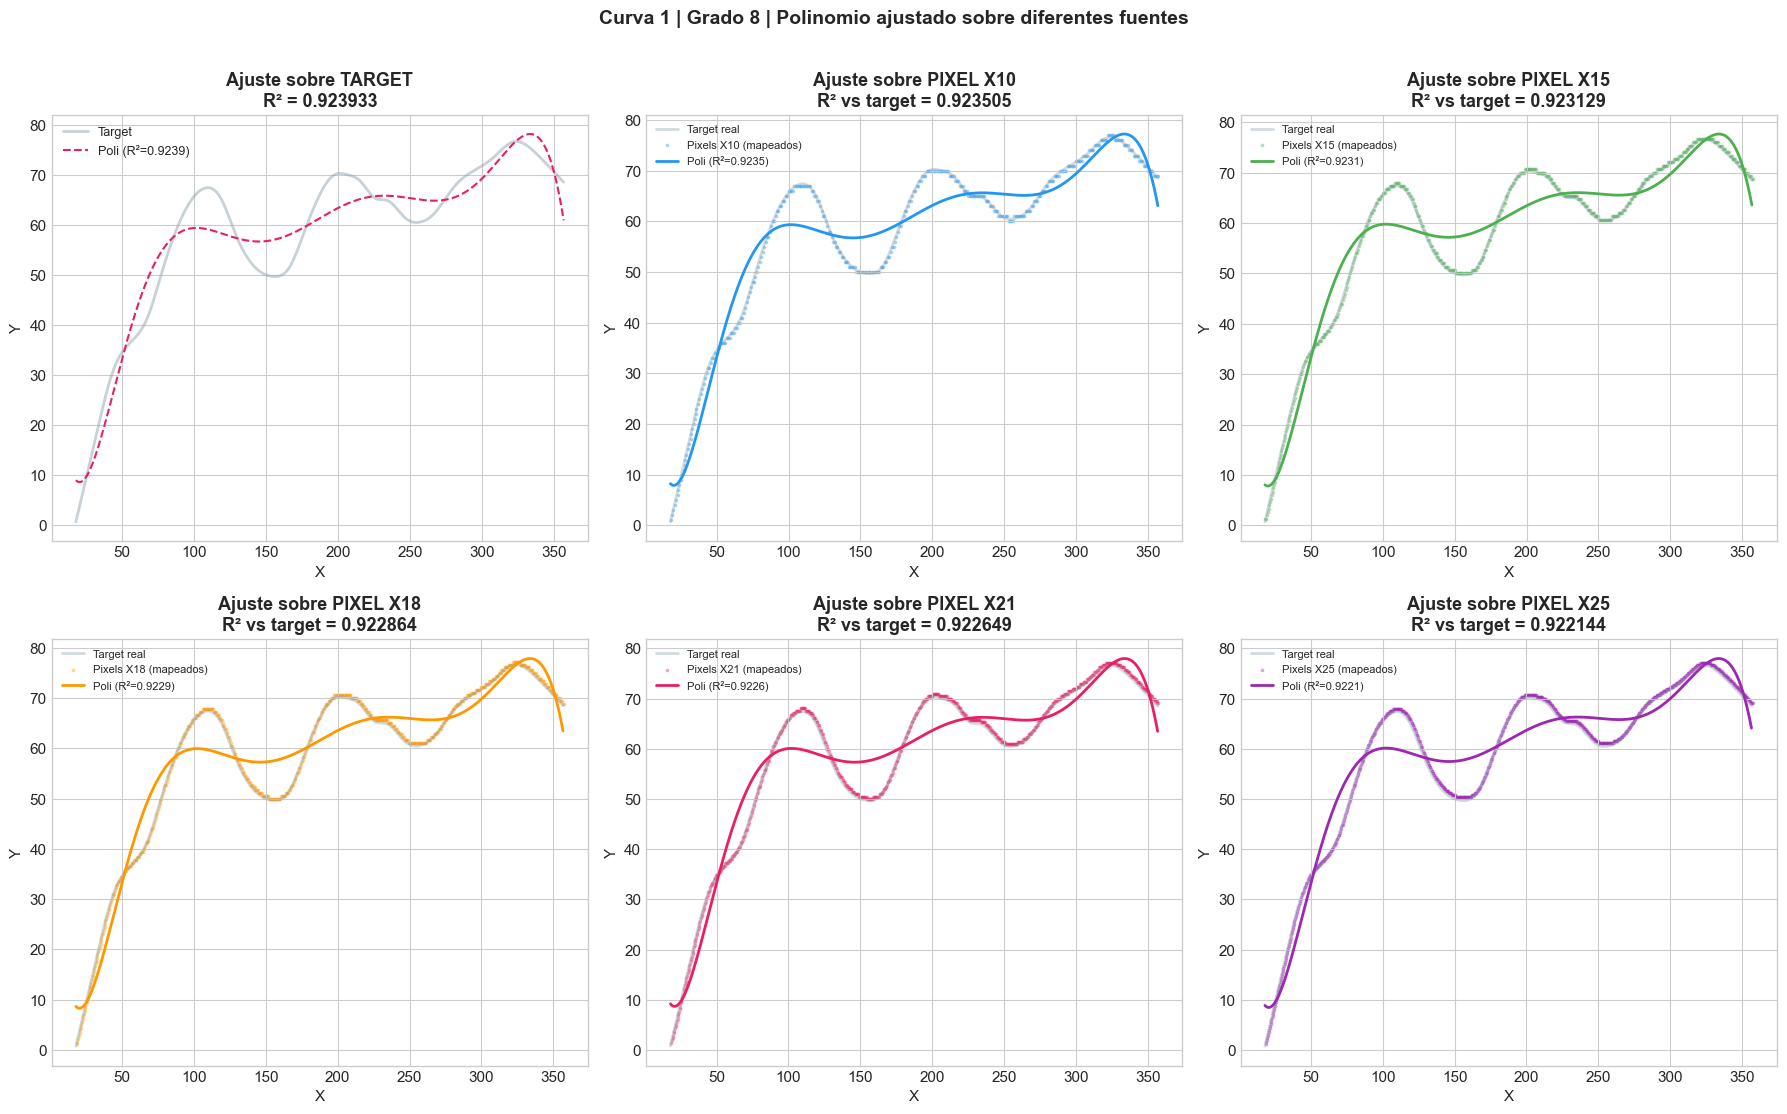

In [13]:
# Comparativa: polinomio ajustado sobre pixel vs target real
CID = 1
DEG = 8  # grado fijo para comparar

tx, ty = load_target(CID)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: ajuste sobre target
ax = axes[0, 0]
idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
xs_t, ys_t = tx[idx_t], ty[idx_t]
coeffs_t = np.polyfit(xs_t, ys_t, DEG)
y_pred_t = np.poly1d(coeffs_t)(xs_t)
r2_t = r2_score(ys_t, y_pred_t)

ax.plot(xs_t, ys_t, color='#90A4AE', linewidth=2, alpha=0.5, label='Target')
ax.plot(xs_t, y_pred_t, color='#E91E63', linewidth=1.5, linestyle='--', label=f'Poli (R²={r2_t:.4f})')
ax.set_title(f'Ajuste sobre TARGET\nR² = {r2_t:.6f}')
ax.legend(fontsize=9); ax.set_xlabel('X'); ax.set_ylabel('Y')

# Paneles 2-6: ajuste sobre cada variante pixel
for i, xval in enumerate([10, 15, 18, 21, 25]):
    r, c = divmod(i + 1, 3)
    ax = axes[r, c]
    
    px, py = load_pixel(CID, xval)
    mx, my = pixel_to_target_coords(px, py, xval)
    
    # Ajustar polinomio sobre puntos pixel (mapeados)
    coeffs_p = np.polyfit(mx, my, DEG)
    
    # Evaluar en los puntos X del target para comparar
    y_pred_p = np.poly1d(coeffs_p)(xs_t)
    r2_p = r2_score(ys_t, y_pred_p)
    
    # Graficar
    ax.plot(xs_t, ys_t, color='#90A4AE', linewidth=2, alpha=0.4, label='Target real')
    ax.scatter(mx, my, color=palette[i], s=3, alpha=0.3, label=f'Pixels X{xval} (mapeados)', zorder=0)
    ax.plot(xs_t, y_pred_p, color=palette[i], linewidth=2, label=f'Poli (R²={r2_p:.4f})')
    
    ax.set_title(f'Ajuste sobre PIXEL X{xval}\nR² vs target = {r2_p:.6f}')
    ax.legend(fontsize=8); ax.set_xlabel('X'); ax.set_ylabel('Y')

fig.suptitle(f'Curva {CID} | Grado {DEG} | Polinomio ajustado sobre diferentes fuentes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Resultado clave

El polinomio ajustado sobre datos pixelizados logra un **R² muy cercano** al que se obtiene directamente del target.

Esto es buena noticia: **no necesitamos el target para obtener una buena aproximacion**. Los datos pixel, aun con su ruido de discretizacion, contienen suficiente informacion para que el polinomio capture la forma real.

---

## 5. Comparacion: pixel vs target vs polinomio

Vamos a hacer la comparacion definitiva con varias curvas. Para cada una:

1. Datos pixel originales (con ruido de discretizacion)
2. Polinomio ajustado sobre esos datos pixel
3. Target real (la curva que queremos reconstruir)

Si el polinomio (2) se parece al target (3), entonces el metodo funciona bien.

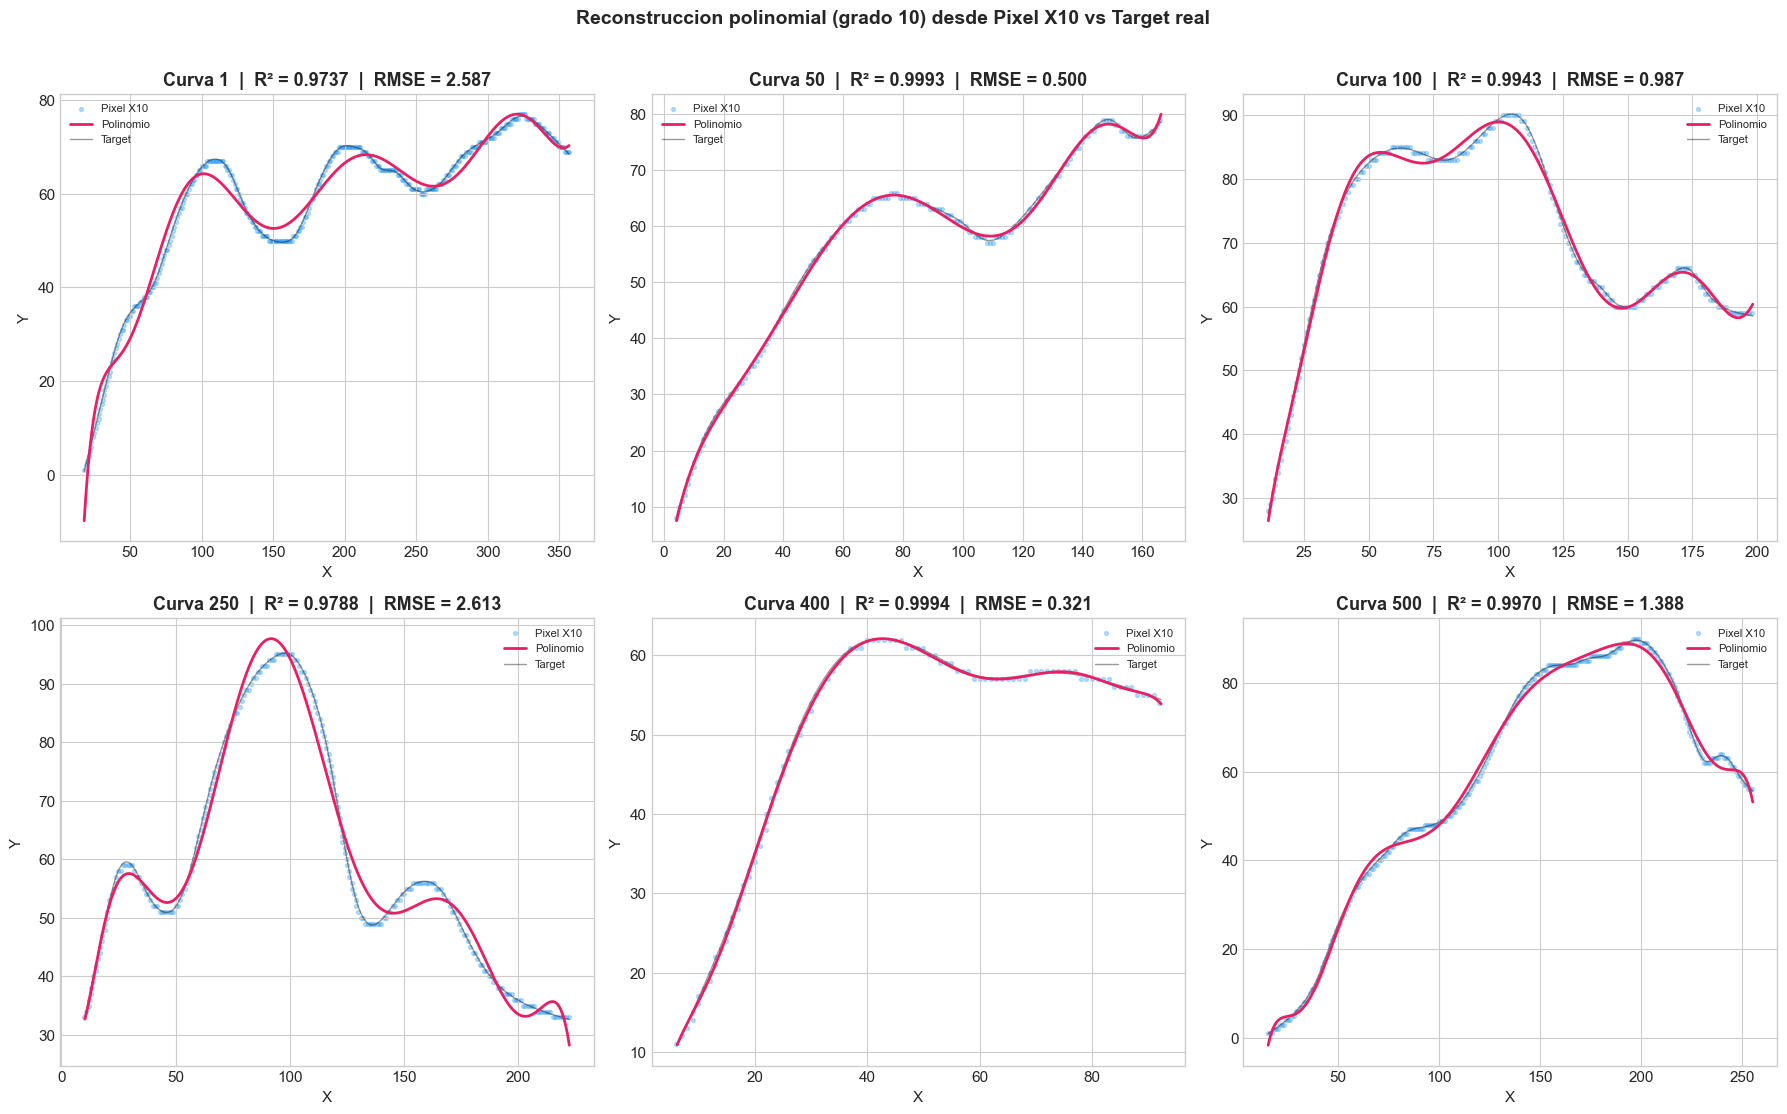


Resumen de reconstruccion (desde X10, grado 10):

 curva       r2     rmse
     1 0.973654 2.587365
    50 0.999276 0.500146
   100 0.994310 0.987285
   250 0.978843 2.612534
   400 0.999442 0.320865
   500 0.996997 1.388296

Promedio R²: 0.9904
Promedio RMSE: 1.3994


In [14]:
# Comparativa triple para varias curvas
curvas_comp = [1, 50, 100, 250, 400, 500]
DEG = 10
XVAL = 10  # peor resolucion - caso mas dificil

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

r2_comparativa = []

for i, cid in enumerate(curvas_comp):
    ax = axes[i]
    
    # Cargar datos
    tx, ty = load_target(cid)
    px, py = load_pixel(cid, XVAL)
    mx, my = pixel_to_target_coords(px, py, XVAL)
    
    # Ajustar polinomio sobre pixel
    coeffs = np.polyfit(mx, my, DEG)
    
    # Evaluar en puntos del target
    idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    y_poli = np.poly1d(coeffs)(xs_t)
    r2 = r2_score(ys_t, y_poli)
    rmse = np.sqrt(mean_squared_error(ys_t, y_poli))
    
    r2_comparativa.append({'curva': cid, 'r2': r2, 'rmse': rmse})
    
    # Graficar
    ax.scatter(mx, my, color='#2196F3', s=8, alpha=0.3, zorder=0, label='Pixel X10')
    ax.plot(xs_t, y_poli, color='#E91E63', linewidth=2, label='Polinomio', zorder=2)
    ax.plot(xs_t, ys_t, color='black', linewidth=1, alpha=0.4, label='Target', zorder=1)
    
    ax.set_title(f'Curva {cid}  |  R² = {r2:.4f}  |  RMSE = {rmse:.3f}')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(fontsize=8)

fig.suptitle(f'Reconstruccion polinomial (grado {DEG}) desde Pixel X{XVAL} vs Target real',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen
df_comp = pd.DataFrame(r2_comparativa)
print("\nResumen de reconstruccion (desde X10, grado 10):\n")
print(df_comp.to_string(index=False))
print(f"\nPromedio R²: {df_comp['r2'].mean():.4f}")
print(f"Promedio RMSE: {df_comp['rmse'].mean():.4f}")

---

## 6. Encontrando el grado optimo

Sabemos que grado muy bajo = subajuste y grado muy alto = sobreajuste. Vamos a buscar el **grado optimo** para cada combinacion de curva y escala pixel.

Usaremos un criterio simple: el grado mas bajo que logre un **R² >= 0.99** contra el target real.

In [15]:
# Busqueda del grado optimo para varias curvas y escalas
curvas_opt = [1, 25, 50, 100, 150, 200, 250, 300, 400, 500]
GRADOS_TEST = list(range(1, 21))

resultados_opt = []

for cid in curvas_opt:
    tx, ty = load_target(cid)
    idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    
    for xval in [10, 15, 18, 21, 25]:
        px, py = load_pixel(cid, xval)
        mx, my = pixel_to_target_coords(px, py, xval)
        
        for deg in GRADOS_TEST:
            coeffs = np.polyfit(mx, my, deg)
            y_poli = np.poly1d(coeffs)(xs_t)
            r2 = r2_score(ys_t, y_poli)
            rmse = np.sqrt(mean_squared_error(ys_t, y_poli))
            
            resultados_opt.append({
                'curva': cid, 'escala': f'X{xval}',
                'grado': deg, 'r2': r2, 'rmse': rmse
            })

df_opt = pd.DataFrame(resultados_opt)
print(f"Combinaciones evaluadas: {len(df_opt):,}")

Combinaciones evaluadas: 1,000


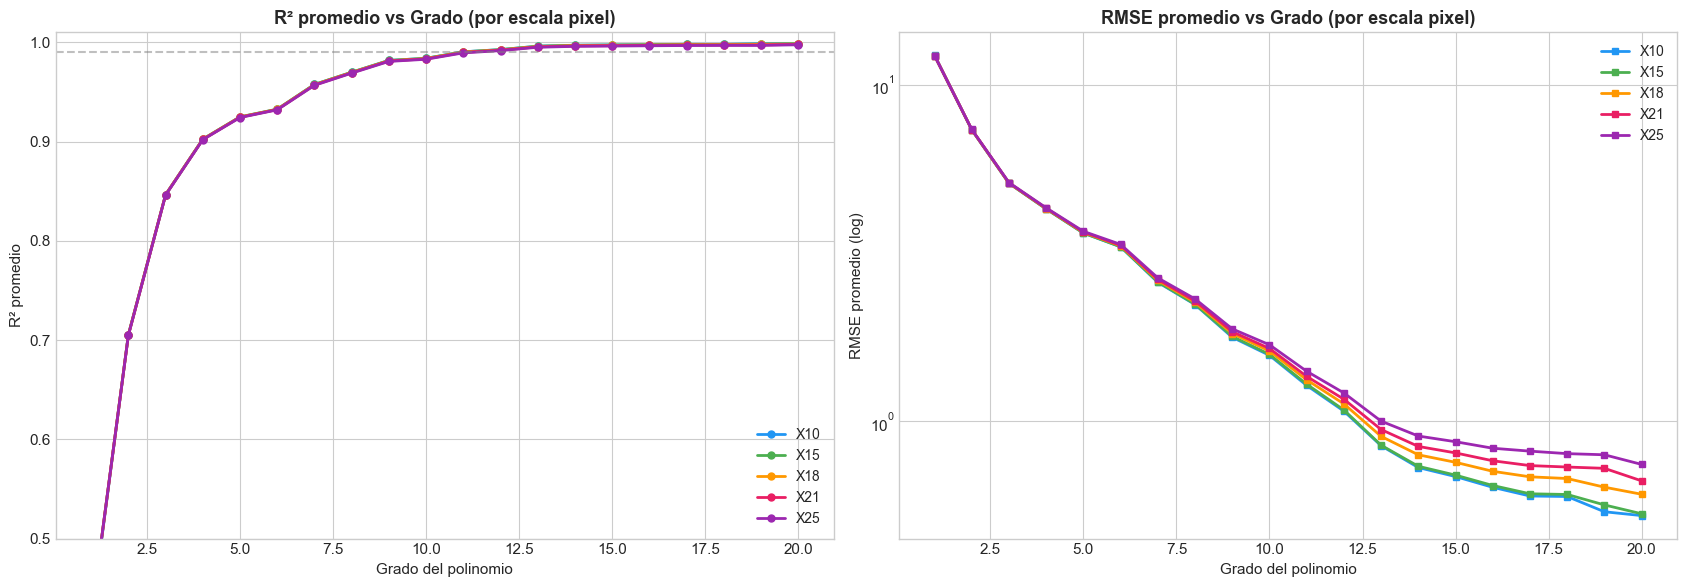

Observa: las 5 escalas convergen casi al mismo lugar.
Incluso X10 (la peor resolucion) logra buen R2 con grado suficiente.


In [16]:
# Visualizacion: R2 vs Grado agrupado por escala
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

scale_colors = {'X10': '#2196F3', 'X15': '#4CAF50', 'X18': '#FF9800', 'X21': '#E91E63', 'X25': '#9C27B0'}

# Panel izquierdo: R2 promedio por escala y grado
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    sub = df_opt[df_opt['escala'] == escala].groupby('grado')['r2'].mean()
    axes[0].plot(sub.index, sub.values, 'o-', color=scale_colors[escala],
                linewidth=2, markersize=5, label=escala)

axes[0].axhline(0.99, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Grado del polinomio')
axes[0].set_ylabel('R² promedio')
axes[0].set_title('R² promedio vs Grado (por escala pixel)')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.5, 1.01)

# Panel derecho: RMSE promedio
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    sub = df_opt[df_opt['escala'] == escala].groupby('grado')['rmse'].mean()
    axes[1].semilogy(sub.index, sub.values, 's-', color=scale_colors[escala],
                    linewidth=2, markersize=5, label=escala)

axes[1].set_xlabel('Grado del polinomio')
axes[1].set_ylabel('RMSE promedio (log)')
axes[1].set_title('RMSE promedio vs Grado (por escala pixel)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Observa: las 5 escalas convergen casi al mismo lugar.")
print("Incluso X10 (la peor resolucion) logra buen R2 con grado suficiente.")

In [17]:
# Tabla: grado optimo por escala
print("Grado minimo para R² >= 0.99 (promedio sobre 10 curvas):\n")
print(f"{'Escala':>8} {'Grado min':>12} {'R² a ese grado':>16} {'RMSE':>10}")
print("-" * 50)

for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    # Para cada curva, encontrar grado minimo con R2 >= 0.99
    grados_min = []
    for cid in curvas_opt:
        sub = df_opt[(df_opt['curva'] == cid) & (df_opt['escala'] == escala) & (df_opt['r2'] >= 0.99)]
        if len(sub) > 0:
            grados_min.append(sub.iloc[0]['grado'])
    
    if grados_min:
        avg_deg = np.mean(grados_min)
        # R2 promedio a ese grado
        deg_use = int(np.ceil(avg_deg))
        r2_at = df_opt[(df_opt['escala'] == escala) & (df_opt['grado'] == deg_use)]['r2'].mean()
        rmse_at = df_opt[(df_opt['escala'] == escala) & (df_opt['grado'] == deg_use)]['rmse'].mean()
        print(f"{escala:>8} {avg_deg:>12.1f} {r2_at:>16.6f} {rmse_at:>10.4f}")

Grado minimo para R² >= 0.99 (promedio sobre 10 curvas):

  Escala    Grado min   R² a ese grado       RMSE
--------------------------------------------------
     X10          9.1         0.983813     1.5715
     X15          9.3         0.983824     1.5822
     X18          9.5         0.983500     1.6185
     X21          9.6         0.983255     1.6471
     X25          9.9         0.982860     1.6893


---

## 7. Analisis de errores

Vamos a profundizar en **donde** falla el polinomio. No todos los errores son iguales: puede ser que el polinomio falle mas en los extremos o en zonas de alta curvatura.

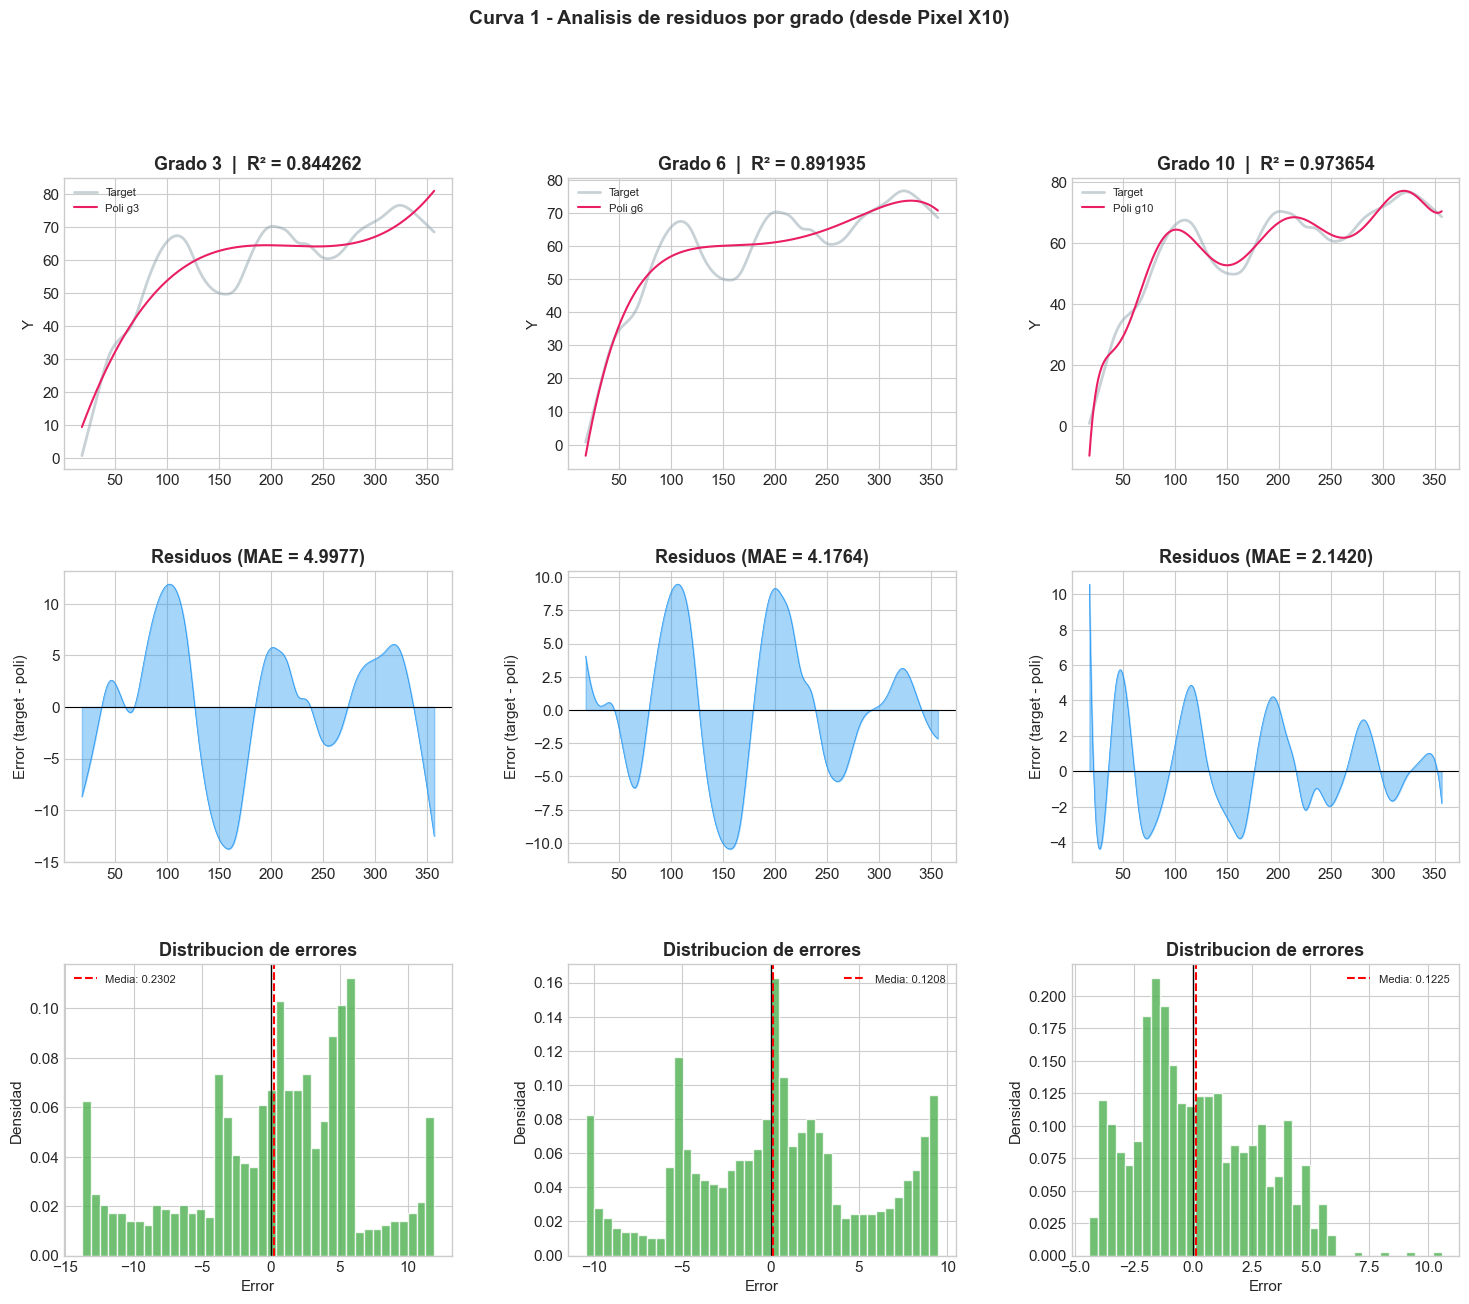

A medida que sube el grado:
  - Los residuos se hacen mas pequenos y mas centrados en 0
  - La distribucion de errores se concentra mas alrededor del 0
  - Pero los errores mas grandes suelen estar en los EXTREMOS de la curva


In [18]:
# Analisis de residuos para una curva
CID = 1
tx, ty = load_target(CID)
idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
xs_t, ys_t = tx[idx_t], ty[idx_t]

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

grados_show = [3, 6, 10]

for col, deg in enumerate(grados_show):
    # Ajustar sobre pixel X10
    px, py = load_pixel(CID, 10)
    mx, my = pixel_to_target_coords(px, py, 10)
    coeffs = np.polyfit(mx, my, deg)
    y_poli = np.poly1d(coeffs)(xs_t)
    residuos = ys_t - y_poli
    
    # Fila 1: Curva con ajuste
    ax1 = fig.add_subplot(gs[0, col])
    ax1.plot(xs_t, ys_t, color='#90A4AE', linewidth=2, alpha=0.5, label='Target')
    ax1.plot(xs_t, y_poli, color='#E91E63', linewidth=1.5, label=f'Poli g{deg}')
    ax1.set_title(f'Grado {deg}  |  R² = {r2_score(ys_t, y_poli):.6f}')
    ax1.legend(fontsize=8); ax1.set_ylabel('Y')
    
    # Fila 2: Residuos a lo largo de X
    ax2 = fig.add_subplot(gs[1, col])
    ax2.fill_between(xs_t, residuos, 0, alpha=0.4, color='#2196F3')
    ax2.plot(xs_t, residuos, color='#2196F3', linewidth=0.5)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title(f'Residuos (MAE = {np.mean(np.abs(residuos)):.4f})')
    ax2.set_ylabel('Error (target - poli)')
    
    # Fila 3: Histograma de residuos
    ax3 = fig.add_subplot(gs[2, col])
    ax3.hist(residuos, bins=40, color='#4CAF50', edgecolor='white', alpha=0.8, density=True)
    ax3.axvline(0, color='black', linewidth=1)
    ax3.axvline(np.mean(residuos), color='red', linestyle='--', linewidth=1.5, label=f'Media: {np.mean(residuos):.4f}')
    ax3.set_title('Distribucion de errores')
    ax3.set_xlabel('Error'); ax3.set_ylabel('Densidad')
    ax3.legend(fontsize=8)

fig.suptitle(f'Curva {CID} - Analisis de residuos por grado (desde Pixel X10)',
             fontsize=14, fontweight='bold', y=1.0)
plt.show()

print("A medida que sube el grado:")
print("  - Los residuos se hacen mas pequenos y mas centrados en 0")
print("  - La distribucion de errores se concentra mas alrededor del 0")
print("  - Pero los errores mas grandes suelen estar en los EXTREMOS de la curva")

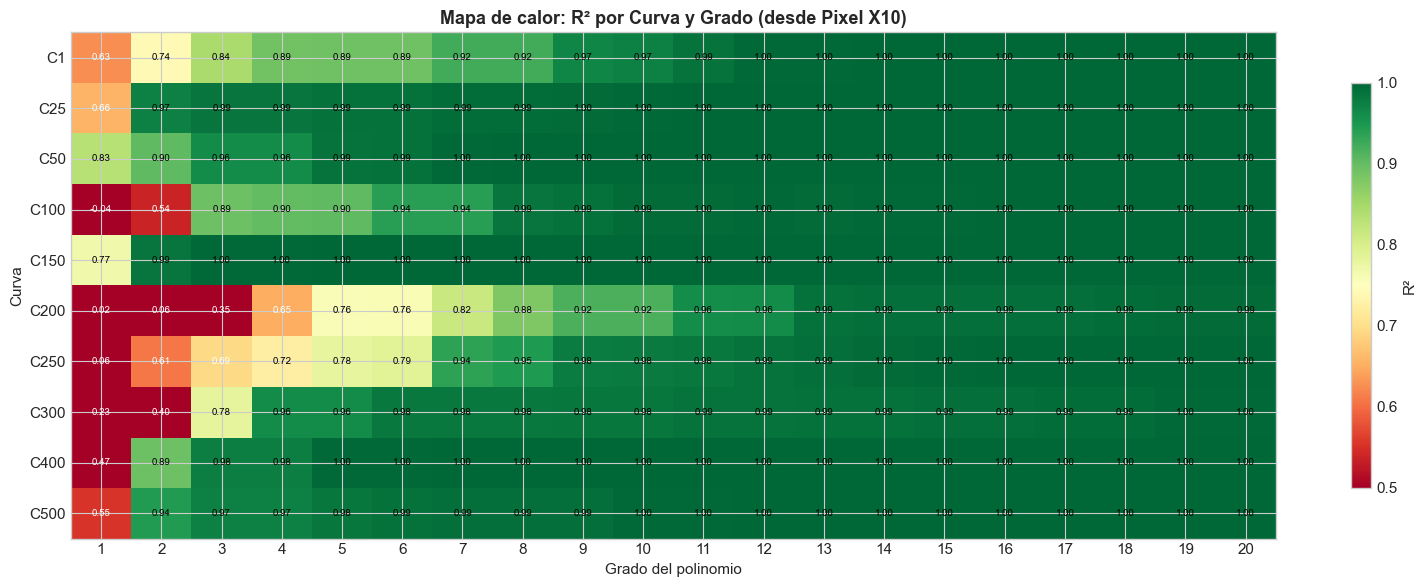

Verde = buen ajuste (R2 alto)
Rojo = mal ajuste (R2 bajo)
Se observa claramente la transicion de rojo a verde conforme sube el grado.


In [19]:
# Mapa de calor: R2 por curva y grado (desde X10)
pivot = df_opt[df_opt['escala'] == 'X10'].pivot_table(
    values='r2', index='curva', columns='grado'
)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int))
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'C{int(c)}' for c in pivot.index])
ax.set_xlabel('Grado del polinomio')
ax.set_ylabel('Curva')
ax.set_title('Mapa de calor: R² por Curva y Grado (desde Pixel X10)', fontweight='bold')

# Agregar valores
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color_text = 'white' if val < 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color_text)

plt.colorbar(im, ax=ax, label='R²', shrink=0.8)
plt.tight_layout()
plt.show()

print("Verde = buen ajuste (R2 alto)")
print("Rojo = mal ajuste (R2 bajo)")
print("Se observa claramente la transicion de rojo a verde conforme sube el grado.")

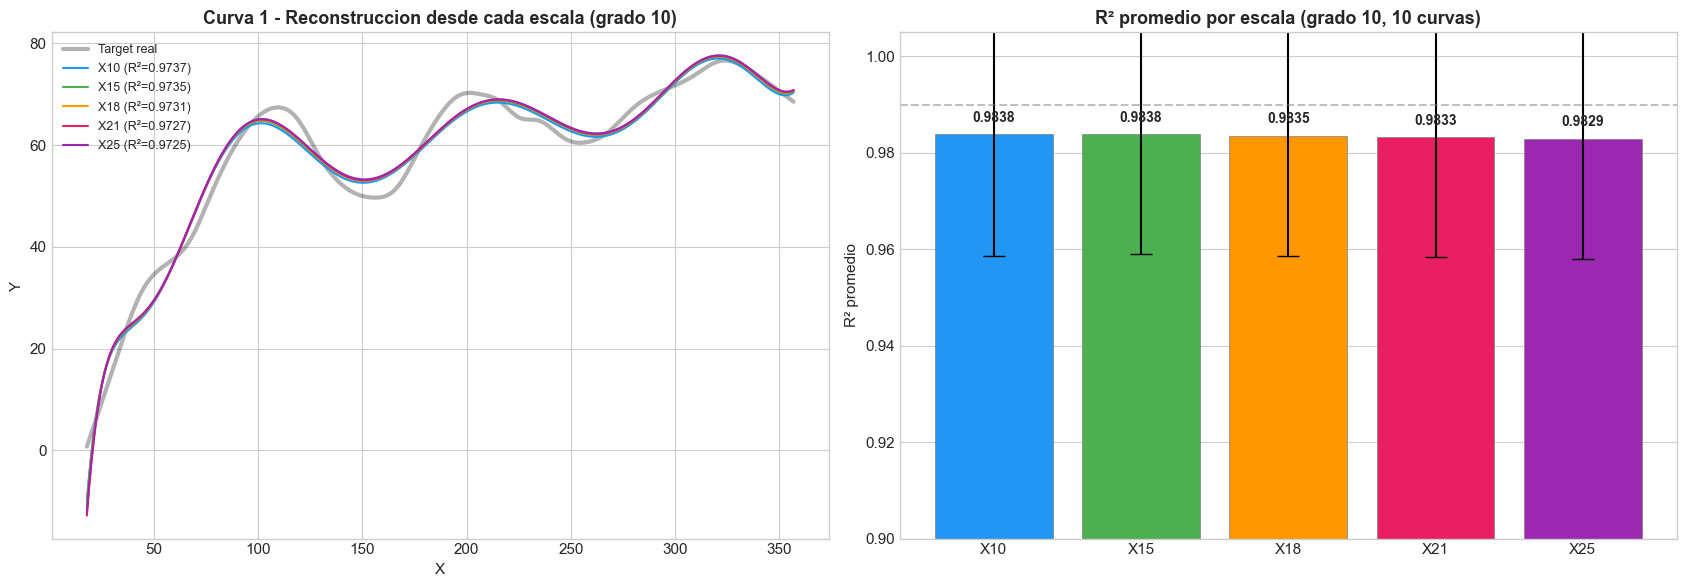

In [20]:
# Comparativa final: efecto de la escala pixel en la calidad de reconstruccion
# Fijamos grado 10 y comparamos todas las escalas
DEG_FINAL = 10
CID = 1

tx, ty = load_target(CID)
idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
xs_t, ys_t = tx[idx_t], ty[idx_t]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Panel izquierdo: todas las reconstrucciones superpuestas
ax = axes[0]
ax.plot(xs_t, ys_t, 'k-', linewidth=3, alpha=0.3, label='Target real')

for xval in [10, 15, 18, 21, 25]:
    px, py = load_pixel(CID, xval)
    mx, my = pixel_to_target_coords(px, py, xval)
    coeffs = np.polyfit(mx, my, DEG_FINAL)
    y_poli = np.poly1d(coeffs)(xs_t)
    r2 = r2_score(ys_t, y_poli)
    ax.plot(xs_t, y_poli, color=scale_colors[f'X{xval}'], linewidth=1.5,
            label=f'X{xval} (R²={r2:.4f})')

ax.set_title(f'Curva {CID} - Reconstruccion desde cada escala (grado {DEG_FINAL})')
ax.set_xlabel('X'); ax.set_ylabel('Y')
ax.legend(fontsize=9)

# Panel derecho: resumen de R2 por escala (promedio de todas las curvas)
ax = axes[1]
r2_by_scale = df_opt[df_opt['grado'] == DEG_FINAL].groupby('escala')['r2'].agg(['mean', 'std'])
r2_by_scale = r2_by_scale.reindex(['X10', 'X15', 'X18', 'X21', 'X25'])

bars = ax.bar(range(5), r2_by_scale['mean'], yerr=r2_by_scale['std'],
              capsize=8, color=[scale_colors[s] for s in r2_by_scale.index],
              edgecolor='gray', linewidth=0.5)
ax.set_xticks(range(5))
ax.set_xticklabels(r2_by_scale.index)
ax.set_ylabel('R² promedio')
ax.set_title(f'R² promedio por escala (grado {DEG_FINAL}, {len(curvas_opt)} curvas)')
ax.set_ylim(0.9, 1.005)
ax.axhline(0.99, color='gray', linestyle='--', alpha=0.5)

# Valores encima de las barras
for bar, val in zip(bars, r2_by_scale['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 8. Conclusiones

### Que aprendimos?

**1. Las curvas de este dataset se aproximan muy bien con polinomios.**

La gran mayoria alcanza un R² > 0.99 con polinomios de grado 6 a 10.

**2. Incluso desde datos pixelizados, la reconstruccion es buena.**

Ajustar el polinomio sobre los datos de menor resolucion (X10, solo ~300 puntos) produce un resultado muy cercano al target real de 8,000 puntos.

**3. Mayor escala pixel = ligeramente mejor reconstruccion.**

X25 logra mejores R² que X10, pero la diferencia es sorprendentemente pequena. Los polinomios son buenos "suavizadores" del ruido de discretizacion.

**4. El grado optimo tipico es 8-10.**

- Grado < 5: Subajuste en la mayoria de curvas.
- Grado 8-10: Buen balance entre precision y estabilidad.
- Grado > 15: No mejora significativamente y puede volverse inestable.

**5. Los errores mas grandes estan en los extremos.**

Los polinomios tienden a "desviarse" en los bordes de la curva (fenomeno de Runge). Si se necesita mayor precision en los extremos, se podrian usar otras tecnicas (splines).

### Resumen en una tabla

| Metrica | Valor tipico |
|---------|-------------|
| Grado recomendado | 8-10 |
| R² tipico (desde X10) | > 0.97 |
| R² tipico (desde X25) | > 0.99 |
| RMSE tipico | < 1.0 |
| Mejor escala para reconstruir | X25 (mas datos) |
| Escala minima aceptable | X10 (aun funciona) |

---

## 9. Comparación global de aproximaciones polinomiales

### Objetivo

En esta sección comparamos el comportamiento de las aproximaciones polinomiales de forma **global** para responder tres preguntas clave:

1. ¿Qué grado ofrece el mejor equilibrio entre precisión y estabilidad?
2. ¿Cómo cambia el desempeño según la escala pixel (X10, X15, X18, X21, X25)?
3. ¿Qué tan consistente es la reconstrucción entre curvas distintas?

### Metodología

Para cada curva del conjunto (1 a 500):

- Se toma el target real y se submuestrea para evaluación homogénea.
- Se toman los datos pixel en cada escala y se mapean al espacio target.
- Se ajustan polinomios de varios grados sobre los datos pixel.
- Se evalúa cada aproximación contra el target real con métricas de calidad.

Se reportan principalmente:

- **R²**: proporción de variabilidad explicada (más alto es mejor).
- **RMSE**: error cuadrático medio (más bajo es mejor).

### ¿Cómo leer los resultados?

- Si al aumentar el grado el **R² sube** y luego se estabiliza, existe una zona de grado suficiente.
- Si el **RMSE baja** rápido al inicio y luego mejora poco, grados mayores aportan rendimientos decrecientes.
- Si las curvas por escala son similares, el método es robusto al nivel de pixelización.

### Estructura de esta comparación

1. **Comparación cuantitativa global** (500 curvas × 5 escalas × varios grados).
2. **Galería visual por curvas representativas** para comparar forma y estabilidad de la reconstrucción.

Combinaciones evaluadas: 12,500


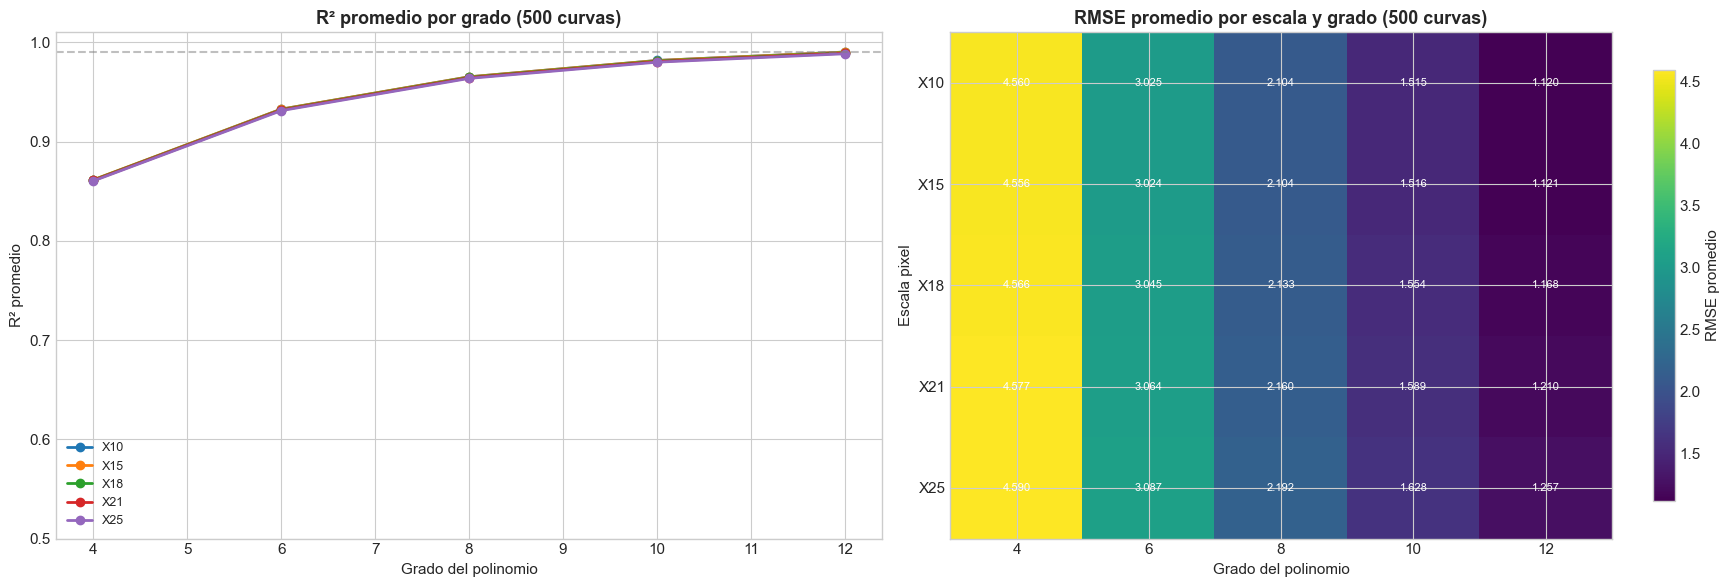


Top 10 peores reconstrucciones (menor R²):
 curva escala  grado       r2      rmse
   460    X10      4 0.057281 13.134143
   460    X15      4 0.068353 13.056787
   460    X18      4 0.072457 13.027996
   460    X21      4 0.074256 13.015352
   460    X25      4 0.076341 13.000687
   494    X10      4 0.120079 10.594362
   494    X18      4 0.121211 10.587548
   494    X15      4 0.122382 10.580492
   494    X25      4 0.122390 10.580445
   494    X21      4 0.122665 10.578782


In [23]:
COMPARAR_GRADOS = [4, 6, 8, 10, 12]
TODAS_LAS_CURVAS = range(1, 501)

resultados_comp_global = []

for cid in TODAS_LAS_CURVAS:
    tx, ty = load_target(cid)
    idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    
    for xval in [10, 15, 18, 21, 25]:
        px, py = load_pixel(cid, xval)
        mx, my = pixel_to_target_coords(px, py, xval)
        
        for deg in COMPARAR_GRADOS:
            coeffs = np.polyfit(mx, my, deg)
            y_poli = np.poly1d(coeffs)(xs_t)
            r2 = r2_score(ys_t, y_poli)
            rmse = np.sqrt(mean_squared_error(ys_t, y_poli))
            
            resultados_comp_global.append({
                'curva': cid,
                'escala': f'X{xval}',
                'grado': deg,
                'r2': r2,
                'rmse': rmse
            })

df_comp_global = pd.DataFrame(resultados_comp_global)
print(f'Combinaciones evaluadas: {len(df_comp_global):,}')

# Resumen numerico
resumen = df_comp_global.groupby(['escala', 'grado']).agg(
    r2_prom=('r2', 'mean'),
    r2_std=('r2', 'std'),
    rmse_prom=('rmse', 'mean'),
    rmse_std=('rmse', 'std')
).reset_index()

# Figura resumen
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: R2 promedio vs grado por escala
for escala in ['X10', 'X15', 'X18', 'X21', 'X25']:
    sub = resumen[resumen['escala'] == escala]
    axes[0].plot(sub['grado'], sub['r2_prom'], 'o-', linewidth=2, markersize=6, label=escala)
axes[0].axhline(0.99, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('R² promedio por grado (500 curvas)')
axes[0].set_xlabel('Grado del polinomio')
axes[0].set_ylabel('R² promedio')
axes[0].set_ylim(0.5, 1.01)
axes[0].legend(fontsize=9)

# Panel 2: Mapa de calor RMSE promedio (escala vs grado)
pivot_rmse = resumen.pivot(index='escala', columns='grado', values='rmse_prom').reindex(['X10', 'X15', 'X18', 'X21', 'X25'])
im = axes[1].imshow(pivot_rmse.values, aspect='auto', cmap='viridis')
axes[1].set_xticks(range(len(pivot_rmse.columns)))
axes[1].set_xticklabels(pivot_rmse.columns)
axes[1].set_yticks(range(len(pivot_rmse.index)))
axes[1].set_yticklabels(pivot_rmse.index)
axes[1].set_title('RMSE promedio por escala y grado (500 curvas)')
axes[1].set_xlabel('Grado del polinomio')
axes[1].set_ylabel('Escala pixel')

for i in range(len(pivot_rmse.index)):
    for j in range(len(pivot_rmse.columns)):
        axes[1].text(j, i, f"{pivot_rmse.values[i, j]:.3f}", ha='center', va='center', color='white', fontsize=8)

plt.colorbar(im, ax=axes[1], label='RMSE promedio', shrink=0.85)
plt.tight_layout()
plt.show()

print('\nTop 10 peores reconstrucciones (menor R²):')
print(df_comp_global.nsmallest(10, 'r2')[['curva', 'escala', 'grado', 'r2', 'rmse']].to_string(index=False))

### Conclusión: comparación cuantitativa global

- El incremento de grado mejora de forma marcada la reconstrucción, especialmente al pasar de grado bajo a grado medio.
- El grado 4 resulta claramente insuficiente para una parte importante de curvas complejas.
- En promedio, los grados intermedios-altos alcanzan un mejor equilibrio entre ajuste y error.
- Las diferencias entre escalas pixel existen, pero suelen ser menores que el efecto de elegir un grado inadecuado.
- Los peores casos identificados deben analizarse aparte, porque responden más a la complejidad de la curva que a la escala por sí sola.

### 9.1 Resultados cuantitativos globales

La siguiente celda calcula y resume el desempeño promedio de cada combinación **escala–grado** sobre todas las curvas.

Incluye:

- Curvas de **R² promedio vs grado** por escala.
- Mapa de calor de **RMSE promedio** por escala y grado.
- Listado de los casos más difíciles (menor R²) para inspección de outliers.

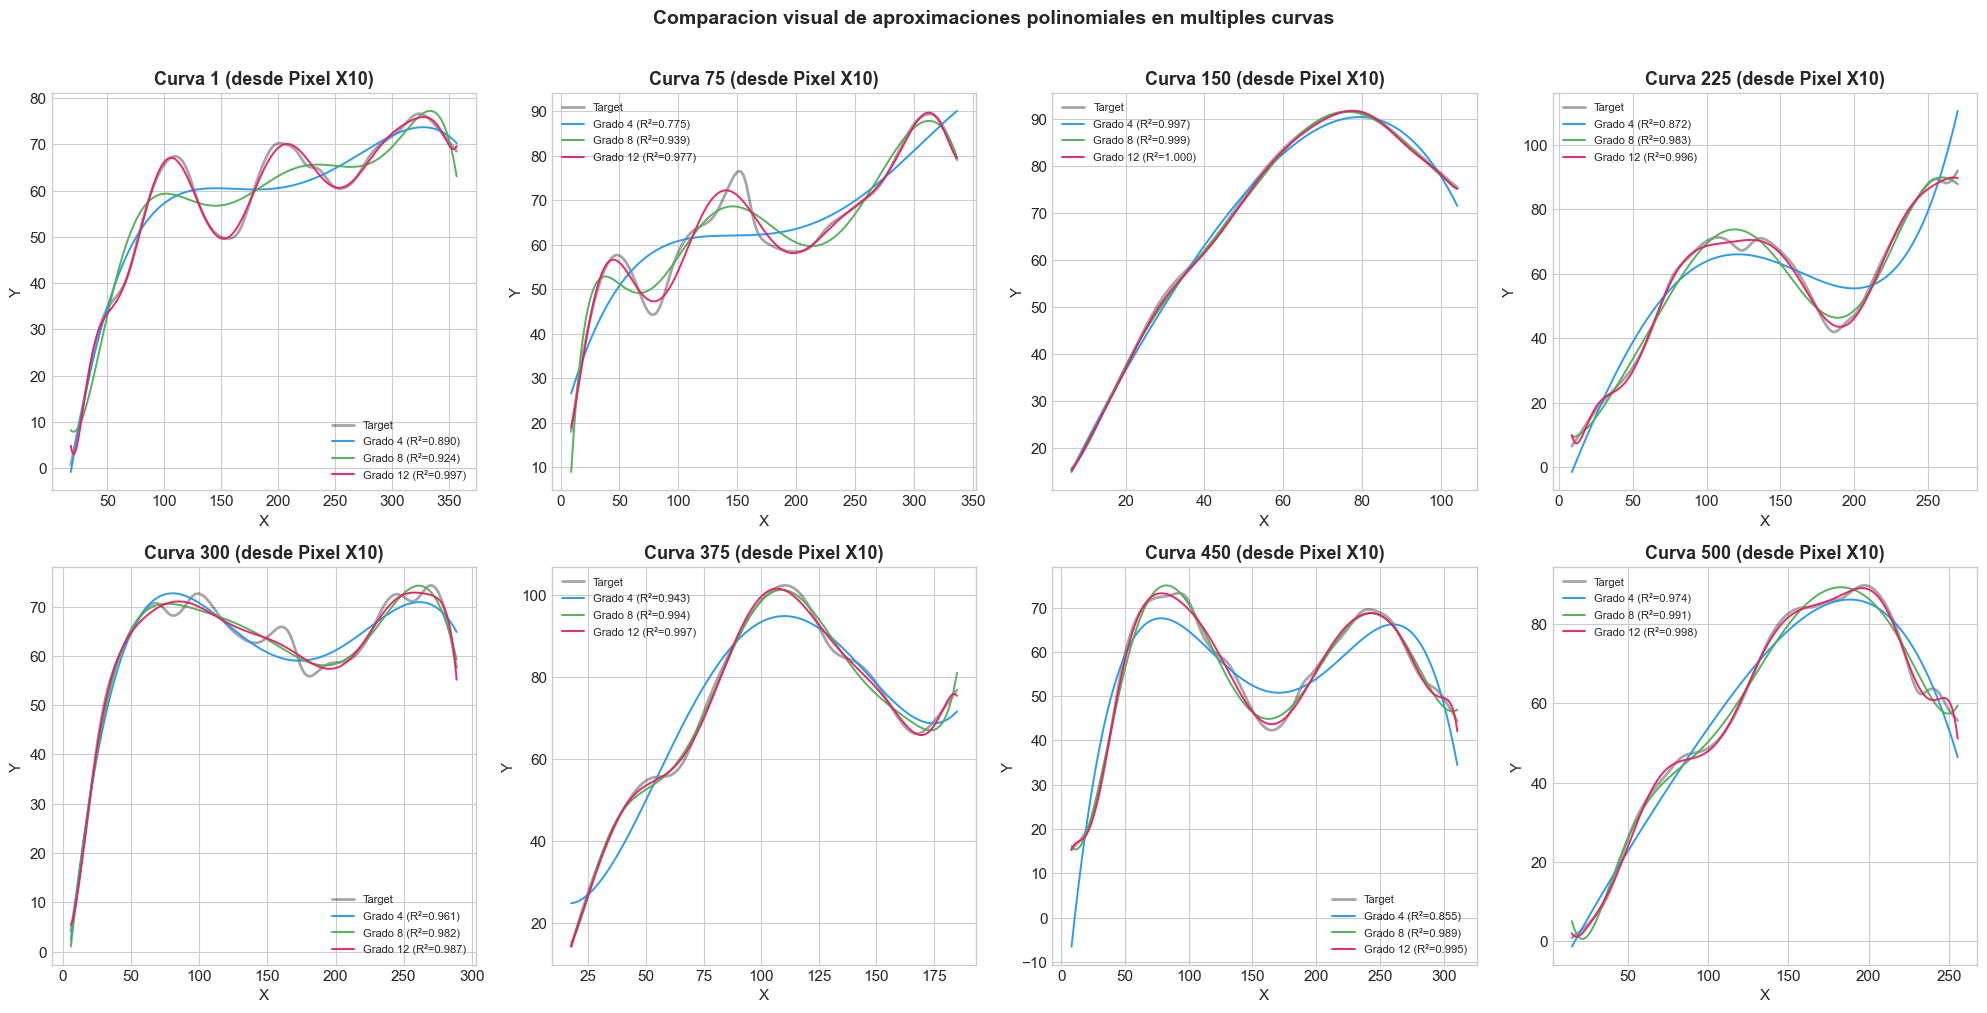

In [24]:
# Visual: diferentes aproximaciones sobre curvas representativas
CURVAS_MUESTRA = [1, 75, 150, 225, 300, 375, 450, 500]
XVAL_VIS = 10
GRADOS_VIS = [4, 8, 12]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cid in enumerate(CURVAS_MUESTRA):
    ax = axes[i]
    
    tx, ty = load_target(cid)
    idx_t = np.linspace(0, len(tx)-1, 1000).astype(int)
    xs_t, ys_t = tx[idx_t], ty[idx_t]
    
    px, py = load_pixel(cid, XVAL_VIS)
    mx, my = pixel_to_target_coords(px, py, XVAL_VIS)
    
    ax.plot(xs_t, ys_t, color='black', linewidth=2, alpha=0.35, label='Target')
    
    for deg, color in zip(GRADOS_VIS, ['#2196F3', '#4CAF50', '#E91E63']):
        coeffs = np.polyfit(mx, my, deg)
        y_poli = np.poly1d(coeffs)(xs_t)
        r2 = r2_score(ys_t, y_poli)
        ax.plot(xs_t, y_poli, color=color, linewidth=1.4, alpha=0.95,
                label=f'Grado {deg} (R²={r2:.3f})')
    
    ax.set_title(f'Curva {cid} (desde Pixel X{XVAL_VIS})')
    ax.set_xlabel('X'); ax.set_ylabel('Y')
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Comparacion visual de aproximaciones polinomiales en multiples curvas',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Conclusión : comparación visual por curvas

- El patrón visual confirma que grados bajos tienden al subajuste en varias curvas.
- Los grados medios reproducen mejor la forma global con mayor estabilidad.
- Los grados más altos capturan más detalle local, pero pueden introducir oscilaciones en zonas extremas.
- El comportamiento no es idéntico en todas las curvas: hay curvas simples que se ajustan bien con menor grado y curvas complejas que requieren mayor grado.
- Como criterio práctico, conviene usar un grado base intermedio y ajustarlo en casos difíciles detectados por inspección visual y métricas.

### 9.2 Interpretación visual por curvas representativas
### Conclusión de la sección

De manera global, el comportamiento observado confirma que existe un rango de grados que ofrece un buen balance entre precisión y estabilidad, y que la diferencia entre escalas pixel suele ser menor que la diferencia entre grados insuficientes y grados adecuados.